In [ ]:
# Uninstall any existing openai installations
#!pip uninstall -y openai
# Install the required version of openai
#!pip install openai==0.28
!pip install openai

In [ ]:
import os
import openai
import pandas as pd
import re
import random
import os
import asyncio
from openai import AsyncOpenAI

In [ ]:
url = 'https://drive.google.com/file/d/1ur5voOHqK7JasJF6uinmQXXvlAxHJ8ni/view?usp=sharing'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

dataset = pd.read_csv(read_url, usecols=['text', 'hatespeech_comb'])

dataset.head()

,text,hatespeech_comb
0,Estou trabalhando num sistema onde haverá comp...,0
1,@SadBoyKevyn \nNunca penses que algo 'é o mais...,0
2,Começa pelo seu namorado @badgalerica https://...,0
3,"o discurso do socialismo pode até ser bonito, ...",0
4,RT @mayaramellon: é cheio de opinião mas não t...,0


In [ ]:
OPENAI_API_KEY="COLOQUE SUA CHAVE AQUI"

In [ ]:
client = AsyncOpenAI(
    # This is the default and can be omitted
    api_key=OPENAI_API_KEY,
)

In [ ]:
from google.colab import files

def save_respostas(respostas_llm):
  df = pd.DataFrame(respostas_llm)
  df.to_excel(f'respostas_chatgpt.xlsx', index=False)

  # Especificar o caminho do arquivo no Google Drive
  files.download(f'respostas_chatgpt.xlsx')

In [ ]:
async def main() -> None:
  respostas_llm = {}

  sentencas = dataset["text"].to_list()
  targets = dataset["hatespeech_comb"].to_list()

  respostas_llm["text"] = sentencas
  respostas_llm["target"] = targets
  respostas_llm['predicted'] = []

  for sentenca in sentencas:

    prompt = f"""
    Você é um moderador de conteúdo. Classifique a frase assim:

    - "1" se a frase contém discurso de ódio (hate speech)
    - "0" se a frase não contém nenhum tipo de discurso de ódio (non-hate speech)


    Regras:
    - Sua saída deve ser apenas um número inteiro (0 ou 1)
    - Não inclua nenhum texto adicional na resposta

    Frase: "{sentenca}"
    """
    response = await client.chat.completions.create(
              model="gpt-4o",
              messages=[{"role": "user", "content": prompt}]
    )

    # Access the content using dot notation instead of square brackets
    respostas_llm['predicted'].append(response.choices[0].message.content)

  save_respostas(respostas_llm)

# Use await directly instead of asyncio.run()
await main()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

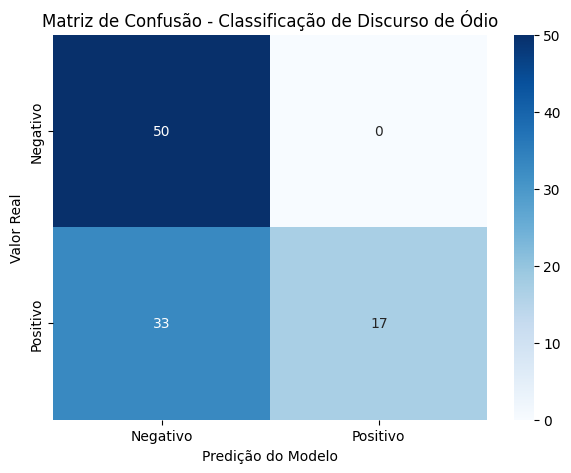

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Carregar o arquivo salvo anteriormente
df = pd.read_excel("respostas_chatgpt.xlsx")

# Garantir que os valores estão como inteiros (0 ou 1)
df["target"] = df["target"].astype(int)
df["predicted"] = df["predicted"].astype(str).str.extract(r"(\d)").astype(int)

# Criar matriz de confusão
cm = confusion_matrix(df["target"], df["predicted"])

# Nomes personalizados
labels = ["Negativo", "Positivo"]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,   # nomes das colunas (predição)
    yticklabels=labels    # nomes das linhas (valores reais)
)

plt.title("Matriz de Confusão - Classificação de Discurso de Ódio")
plt.xlabel("Predição do Modelo")
plt.ylabel("Valor Real")
plt.show()
